Calibration of sound level (dB) of natural speech stimuli (thus with time-varying energy).

1. We create speech-shaped noise, so a noise signal whose spectral content matches the one of the speech material in our dataset. See procedure below.
2. Measure the SL(dB) with A noise weighting and HEQ config files for left and right ear respectively on REW + EARS Serial 860-3244
3. Which integration window should I chose? In principle is shouldn't matter now becouse we have stable energy over time.
4. The measured sound level with Psychopy volume set to 1, Windows volume set to 80% and Scarlett knob set to 3/4, and headphones in the booth is?

SL(dB) = 

In [7]:
import os
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

In [8]:
rmse = lambda x: np.sqrt(np.mean(np.abs(x)**2))

Loaded ./input/stimuli/song/AT0001.wav with samplerate 44100 and shape (63872, 2)
Loaded ./input/stimuli/song/AT0002.wav with samplerate 44100 and shape (38718, 2)
Loaded ./input/stimuli/song/AT0003.wav with samplerate 44100 and shape (69456, 2)
Loaded ./input/stimuli/song/AT0004.wav with samplerate 44100 and shape (46656, 2)
Loaded ./input/stimuli/song/AT0005.wav with samplerate 44100 and shape (43128, 2)
Loaded ./input/stimuli/song/AT0006.wav with samplerate 44100 and shape (62048, 2)
Loaded ./input/stimuli/song/AT0007.wav with samplerate 44100 and shape (43746, 2)
Loaded ./input/stimuli/song/AT0008.wav with samplerate 44100 and shape (52038, 2)
Loaded ./input/stimuli/song/AT0009.wav with samplerate 44100 and shape (61918, 2)
Loaded ./input/stimuli/song/AT0010.wav with samplerate 44100 and shape (47970, 2)
Loaded ./input/stimuli/song/AT0011.wav with samplerate 44100 and shape (37100, 2)
Loaded ./input/stimuli/song/AT0012.wav with samplerate 44100 and shape (61120, 2)
Loaded ./input/s

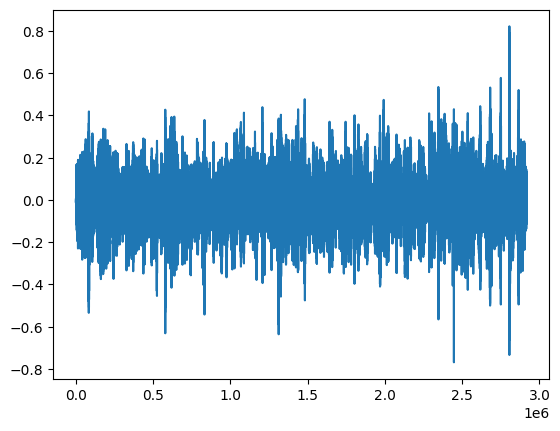

In [15]:
# Create concatenated files
input_dir1 = './input/stimuli/song/'
files1 = [os.path.join(input_dir1, f) for f in os.listdir(input_dir1) if f.endswith('.wav')]

input_dir2 = './input/stimuli/speech/'
files2 = [os.path.join(input_dir2, f) for f in os.listdir(input_dir2) if f.endswith('.wav')]

files = files1 + files2

# Concatenate all the audio files
audio_data = []
for file in files:
    data, samplerate = sf.read(file)
    print(f"Loaded {file} with samplerate {samplerate} and shape {data.shape}")

    # If the audio is stereo, take the first channel
    if len(data.shape) > 1:
        data = data[:, 0]
        data = np.squeeze(data)

    audio_data.append(data)

concatenated_audio = np.concatenate(audio_data)

# Get T of concatenated audio
T = len(concatenated_audio)/samplerate
print(f"Total duration of the audio: {T}")
plt.plot(concatenated_audio)

# Compute the RMS of the concatenated audio
rms_original = _rms(concatenated_audio, ac=False, axis=-1)
print(f"RMS of the concatenated audio: {rms_original}")

rms_original = rmse(concatenated_audio)
print(f"RMS of the concatenated audio: {rms_original}")

-6.938893903907228e-17
0.05987585244944842
0.059875852449448354


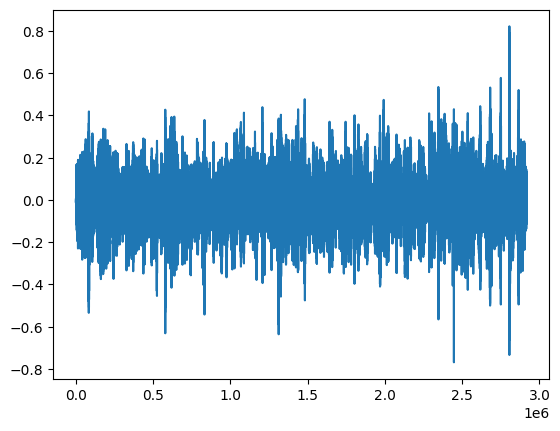

In [18]:
# Test first what's the reconstruction error of ifft(fft(x))
S = np.fft.rfft(concatenated_audio)
r = np.fft.irfft(S)
plt.plot(r)

print(rmse(r) - rmse(concatenated_audio))
print(rmse(concatenated_audio))
print(rmse(r))

-2.8837644980399257e-05
0.05987585244944842
0.059847014804468024


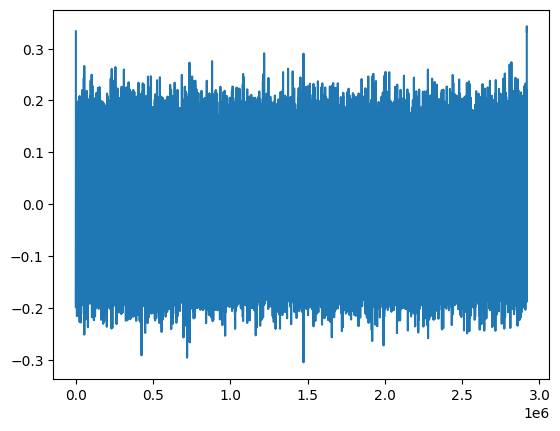

In [31]:
# Compute fft
S = np.fft.rfft(concatenated_audio)

# Get magnitude and phase
mag = np.abs(S)
phase = np.angle(S)

# randomize phase
idx = np.random.permutation(len(phase))
Sr = mag * np.exp(2* np.pi * 1j * phase[idx])
# Sr = mag * np.exp(1j * phase[idx])

# Invert back to time domain
r_random = np.fft.irfft(Sr)

# Remove first and last samples 
r_random = r_random[10:-10]

# Plot
plt.plot(r_random)

# Save the inverted audio
output_file = 'calibration_sound_speech2song.wav'
sf.write(output_file, r_random, samplerate)

print(rmse(r_random) - rmse(concatenated_audio))
print(rmse(concatenated_audio))
print(rmse(r_random))